# We can review 10% of the banks. Would looking at their recent history help us choose?

Study 1 ranked banks by predicted next-quarter deposit growth. Here we keep those forecasts and ask whether eight quarters of the same five inputs give us useful additional information.

First, compare the lists. Then look at three actual banks. Finally, check how many banks in each list went on to have growth in the lowest 10% of their quarter.

**This is a retrospective comparison of three already-inspected 2024 quarters.** Report publication dates and historical revisions are not reconstructed. The assumed review budget is 10%; operational benefit has not been measured.

In [1]:
# EXEMPLAR: bootstrap
import os
from pathlib import Path
import textwrap

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mpl-cache"))
import json
from itertools import combinations
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import get_plotlyjs
from wm_notecards import WMTheme, init_notebook
from wm_notecards.cards import preview_card, takeaway_card
from wm_notecards.charts import style_fig_wm, wm_render_figure_card
from wm_notecards.tables import wm_render_styler
from deposit_experiment import FEATURES
from experiments.review_history.run import run_study

ROOT = Path.cwd()
OUT = ROOT / "experiments/review_history/outputs"
assert (ROOT / "growth_outputs/frozen_forecasts/manifest.json").is_file()
tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.experimental.enable_op_determinism()
theme = WMTheme(width=860, height=480, card_bg="#FFFFFF", plot_bg="#FFFFFF")
init_notebook()
display(HTML("<script>" + get_plotlyjs() + "</script>"))
display(
    HTML(
        "<style>.jp-RenderedMarkdown{max-width:940px;margin:auto;line-height:1.65}.jp-OutputArea-output{overflow-x:auto}</style>"
    )
)


# Adapt the existing notebook table and chart helpers.
def table(frame, title, formats=None):
    styled = frame.style.hide(axis="index").format(formats or {}, na_rep="Unavailable")
    wm_render_styler(styled, theme=theme, title=title)


def chart(figure, name, title, subtitle, height=480):
    style_fig_wm(figure, title=title, subtitle=subtitle, theme=theme, category_policy="preserve")
    title_lines = textwrap.wrap(title, 55)
    subtitle_lines = textwrap.wrap(subtitle, 105)
    heading = (
        "<b>"
        + "<br>".join(title_lines)
        + '</b><br><span style="font-size:14px">'
        + "<br>".join(subtitle_lines)
        + "</span>"
    )
    figure.update_layout(
        height=height,
        width=860,
        font=dict(family="Arial", size=13, color="#222222"),
        title=dict(
            text=heading,
            x=0.025,
            xanchor="left",
            y=0.975,
            yanchor="top",
            pad=dict(t=0),
            font=dict(size=24, family="Arial"),
        ),
        margin=dict(l=100, r=40, t=60 + 30 * len(title_lines) + 20 * len(subtitle_lines), b=110),
        legend=dict(font=dict(size=12), title_text="", orientation="h", y=-0.18, x=0),
    )
    figure.update_xaxes(
        tickfont=dict(size=12, family="Arial"),
        title_font=dict(size=13, family="Arial"),
        automargin=True,
    )
    figure.update_yaxes(
        tickfont=dict(size=12, family="Arial"),
        title_font=dict(size=13, family="Arial"),
        automargin=True,
    )
    figure.update_annotations(font=dict(size=12, family="Arial"))
    figure.update_layout(paper_bgcolor="#FFFFFF", plot_bgcolor="#FFFFFF")
    display(
        HTML(
            figure.to_html(
                full_html=False,
                include_plotlyjs=False,
                config={"responsive": True, "displaylogo": False},
            )
        )
    )

## The same banks, the same review budget

The original forecasts used five current-quarter inputs. Each anomaly detector receives eight quarters of those inputs. Eight growth calculations require nine underlying deposit reports. Undefined values stay unavailable.

We preserve the original lists, then build separate matched-population lists. Future outcomes do not decide who can enter anomaly training.

In [2]:
def feature_histories(scoring_rows):
    """Keep eight consecutive, finite feature vectors, without filling gaps."""
    rows = scoring_rows.sort_values(["CERT", "date"]).reset_index(drop=True)
    grouped = rows.groupby("CERT", sort=False)
    quarters = np.column_stack([grouped.quarter_number.shift(lag) for lag in range(7, -1, -1)])
    blocks = [grouped[list(FEATURES)].shift(lag).to_numpy() for lag in range(7, -1, -1)]
    values = np.stack(blocks, axis=1)
    consecutive = np.isfinite(quarters).all(axis=1) & (np.diff(quarters, axis=1) == 1).all(axis=1)
    finite = np.isfinite(values).all(axis=(1, 2))
    eligible = consecutive & finite
    audit = rows[["CERT", "NAME", "date", "Outcome status"]].copy()
    audit["history_eligible"] = eligible
    audit["exclusion_reason"] = np.select(
        [~consecutive, ~finite],
        [
            "Fewer than eight consecutive input-eligible quarters",
            "Nonfinite feature in eight-quarter history",
        ],
        default="Eligible",
    )
    return rows.loc[eligible].reset_index(drop=True), values[eligible], audit

In [3]:
def standardize_histories(training, validation, evaluation):
    """Fit each quarter-feature slot using training histories alone."""
    scaler = StandardScaler().fit(training.reshape(len(training), -1))
    arrays = [
        scaler.transform(values.reshape(len(values), -1))
        for values in (training, validation, evaluation)
    ]
    return scaler, arrays

## Start with the simple rules

Ridge and the MLP select the lowest forecast growth. The equity rule selects the lowest current equity/assets ratio. A size-only control selects the largest deposit balances.

PCA learns a linear reconstruction of the histories. Isolation Forest scores histories that are easier to isolate with random splits. The dense autoencoder learns a nonlinear reconstruction. Larger reconstruction errors receive higher priority for PCA and the autoencoder.

The autoencoder uses a flattened history: quarter slots run oldest to newest, and each slot contains the five features in the listed order. It has no recurrence or attention. Its settings are fixed before evaluation.

In [4]:
def reconstruction_error(actual, reconstructed, feature_count):
    """Return mean squared error and its contribution by original input."""
    squared = np.square(actual - reconstructed)
    by_input = squared.reshape(len(actual), 8, feature_count).sum(axis=1)
    total = by_input.sum(axis=1, keepdims=True)
    shares = np.divide(by_input, total, out=np.zeros_like(by_input), where=total != 0)
    return squared.mean(axis=1), shares

In [5]:
def fit_pca(training):
    """Use training variance to choose the smallest sufficient dimension."""
    model = PCA(svd_solver="full").fit(training)
    count = int(np.searchsorted(np.cumsum(model.explained_variance_ratio_), 0.90) + 1)
    model = PCA(n_components=count, svd_solver="full").fit(training)
    return model

In [6]:
def fit_isolation_forest(training, seed):
    model = IsolationForest(
        n_estimators=300,
        max_samples=min(256, len(training)),
        contamination="auto",
        random_state=seed,
        n_jobs=2,
    )
    return model.fit(training)

In [7]:
def build_autoencoder(input_count, seed):
    """A dense reconstruction model on fixed quarter-feature slots."""
    tf.keras.utils.set_random_seed(seed)
    encoder = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(input_count,)),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(4),
        ],
        name="encoder",
    )
    decoder = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(4,)),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(input_count),
        ],
        name="decoder",
    )
    model = tf.keras.Sequential([tf.keras.Input(shape=(input_count,)), encoder, decoder])
    optimizer = tf.keras.optimizers.Adam(0.001)
    optimizer.build(model.trainable_variables)
    model.compile(optimizer=optimizer, loss="mse")
    return model

In [8]:
def fit_autoencoder(training, validation, seed):
    """Restore the best validation reconstruction weights, never event-selected."""
    model = build_autoencoder(training.shape[1], seed)
    options = tf.data.Options()
    options.threading.private_threadpool_size = 2
    train = training.astype("float32")
    valid = validation.astype("float32")
    batches = (
        tf.data.Dataset.from_tensor_slices((train, train))
        .shuffle(len(train), seed=seed)
        .batch(256)
        .with_options(options)
    )
    checks = tf.data.Dataset.from_tensor_slices((valid, valid)).batch(256).with_options(options)
    stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    history = model.fit(
        batches, validation_data=checks, epochs=100, callbacks=[stopping], verbose=0, shuffle=False
    )
    return model, history.history

## Fit the declared methods, then freeze their scores

The runner uses the definitions shown above and ordinary imports. It saves the eligibility audit, fitted models, training histories, and a score fingerprint before evaluating deposit outcomes. Seed 42 is primary; 7 and 99 remain in every receipt. The same methods also run without `log_deposits`.

Training history endpoints stop in September 2022. Validation endpoints are Q1–Q3 of 2023. Evaluation endpoints are Q1–Q3 of 2024. The runner source is included in the package at `experiments/review_history/run.py`.

Population,Bank-quarter rows
original,13532
expanded,13618
original_complete,13490
expanded_complete,13576



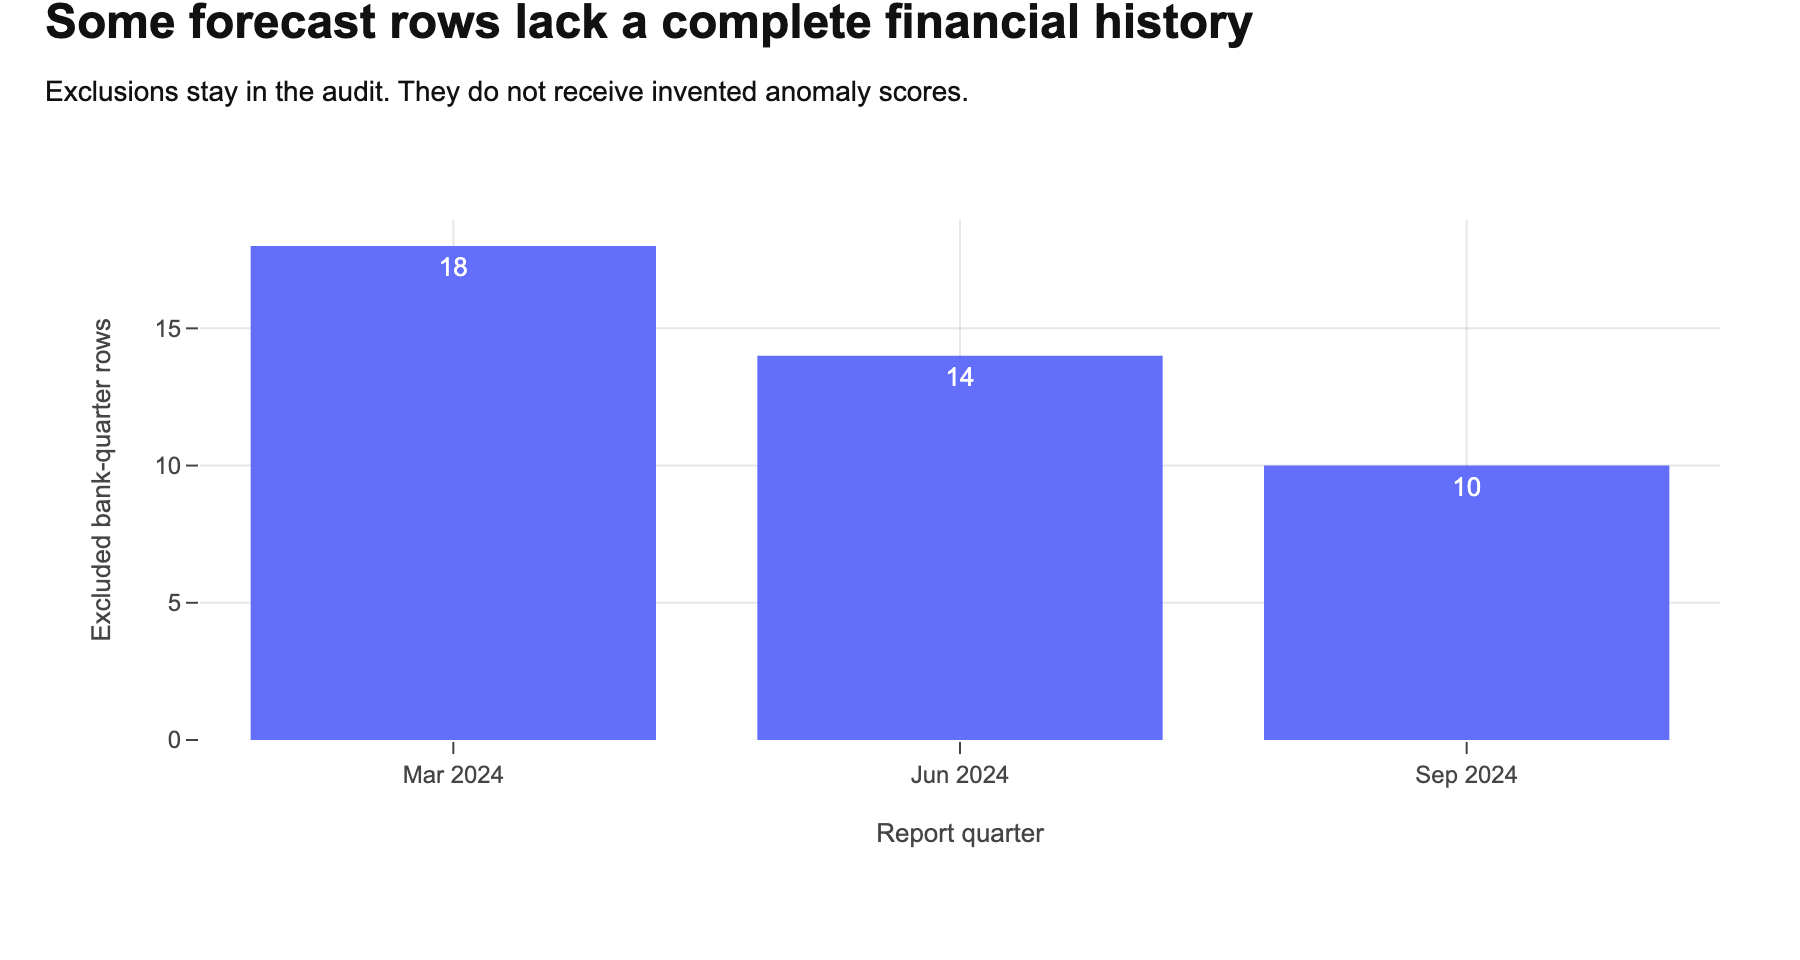

date,exclusion_reason,rows
2024-03-31,Eligible,4548
2024-03-31,Fewer than eight consecutive input-eligible quarters,18
2024-06-30,Eligible,4523
2024-06-30,Fewer than eight consecutive input-eligible quarters,14
2024-09-30,Eligible,4505
2024-09-30,Fewer than eight consecutive input-eligible quarters,10


Original selected rows without anomaly scores: {'Ridge original selected': 5, 'MLP original selected': 7}


In [9]:
if os.environ.get("REVIEW_HISTORY_REFIT", "1") == "1":
    run_study(ROOT, OUT)
plan = json.loads((OUT / "plan.json").read_text())
coverage = pd.read_csv(OUT / "coverage.csv")
# EXEMPLAR: missingness-evidence
counts = pd.DataFrame(
    {
        "Population": list(plan["population_counts"]),
        "Bank-quarter rows": list(plan["population_counts"].values()),
    }
)
table(counts, "The original sample and the two complete-history comparisons")
fig = px.bar(
    coverage.loc[coverage.exclusion_reason.ne("Eligible")],
    x="date",
    y="rows",
    color="exclusion_reason",
    text="rows",
)
fig.update_xaxes(
    type="category",
    title="Report quarter",
    tickvals=coverage.date.unique(),
    ticktext=pd.to_datetime(coverage.date.unique()).strftime("%b %Y"),
)
fig.update_yaxes(title="Excluded bank-quarter rows")
chart(
    fig,
    "history_coverage",
    "Some forecast rows lack a complete financial history",
    "Exclusions stay in the audit. They do not receive invented anomaly scores.",
)
table(coverage, "Every quarter and exclusion reason")
original_audit = pd.read_csv(OUT / "original_list_audit.csv")
unavailable = original_audit.loc[~original_audit.anomaly_score_available]
print(
    "Original selected rows without anomaly scores:",
    unavailable[["Ridge original selected", "MLP original selected"]].sum().to_dict(),
)

## Do the lists agree?

Both methods can select 10% and still choose different banks. Start with Ridge and PCA in March 2024. Each bank belongs in exactly one of four groups.

In [10]:
def review_flags(rows, scores):
    """All scores point upward toward review priority; CERT resolves ties."""
    flags = pd.DataFrame(False, index=rows.index, columns=scores.columns)
    for _, quarter in rows.groupby("date"):
        capacity = int(np.ceil(0.10 * len(quarter)))
        for method in scores.columns:
            ranked = pd.DataFrame(
                {"score": scores.loc[quarter.index, method], "CERT": quarter.CERT}
            )
            if not np.isfinite(ranked.score).all():
                raise ValueError(
                    f"Unavailable scores cannot enter a common-population list: {method}"
                )
            chosen = (
                ranked.sort_values(["score", "CERT"], ascending=[False, True]).head(capacity).index
            )
            flags.loc[chosen, method] = True
    return flags

In [11]:
def list_overlaps(rows, flags):
    """Keep exact quarterly denominators; pool counts rather than percentages."""
    records = []
    for date, quarter in rows.groupby("date"):
        for left, right in combinations(flags.columns, 2):
            a, b = flags.loc[quarter.index, left], flags.loc[quarter.index, right]
            shared, union = int((a & b).sum()), int((a | b).sum())
            records.append(
                {
                    "date": str(date.date()),
                    "left": left,
                    "right": right,
                    "eligible": len(quarter),
                    "left_count": int(a.sum()),
                    "right_count": int(b.sum()),
                    "shared": shared,
                    "left_share": shared / a.sum(),
                    "right_share": shared / b.sum(),
                    "jaccard": shared / union,
                    "random_expected": a.sum() * b.sum() / len(quarter),
                }
            )
    result = pd.DataFrame(records)
    sums = (
        result.groupby(["left", "right"])[
            ["eligible", "left_count", "right_count", "shared", "random_expected"]
        ]
        .sum()
        .reset_index()
    )
    sums["date"] = "All three quarters"
    sums["left_share"] = sums.shared / sums.left_count
    sums["right_share"] = sums.shared / sums.right_count
    sums["jaccard"] = sums.shared / (sums.left_count + sums.right_count - sums.shared)
    return pd.concat([result, sums], ignore_index=True)

In [12]:
def choose_examples(rows, scores, flags):
    """Choose March cases before inspecting identities or subsequent events."""
    march = rows.loc[rows.date.eq("2024-03-31")].copy()
    groups = {
        "Both": flags.Ridge & flags.PCA,
        "Forecast only": flags.Ridge & ~flags.PCA,
        "Anomaly only": ~flags.Ridge & flags.PCA,
    }
    selected = []
    for group, mask in groups.items():
        candidates = march.loc[mask.reindex(march.index)].copy()
        method = "Ridge" if group == "Forecast only" else "PCA"
        candidates["priority"] = scores.loc[candidates.index, method]
        if candidates.empty:
            selected.append({"group": group, "CERT": None, "NAME": "Category empty"})
        else:
            bank = candidates.sort_values(["priority", "CERT"], ascending=[False, True]).iloc[0]
            selected.append({"group": group, "CERT": int(bank.CERT), "NAME": bank.NAME})
    return pd.DataFrame(selected)


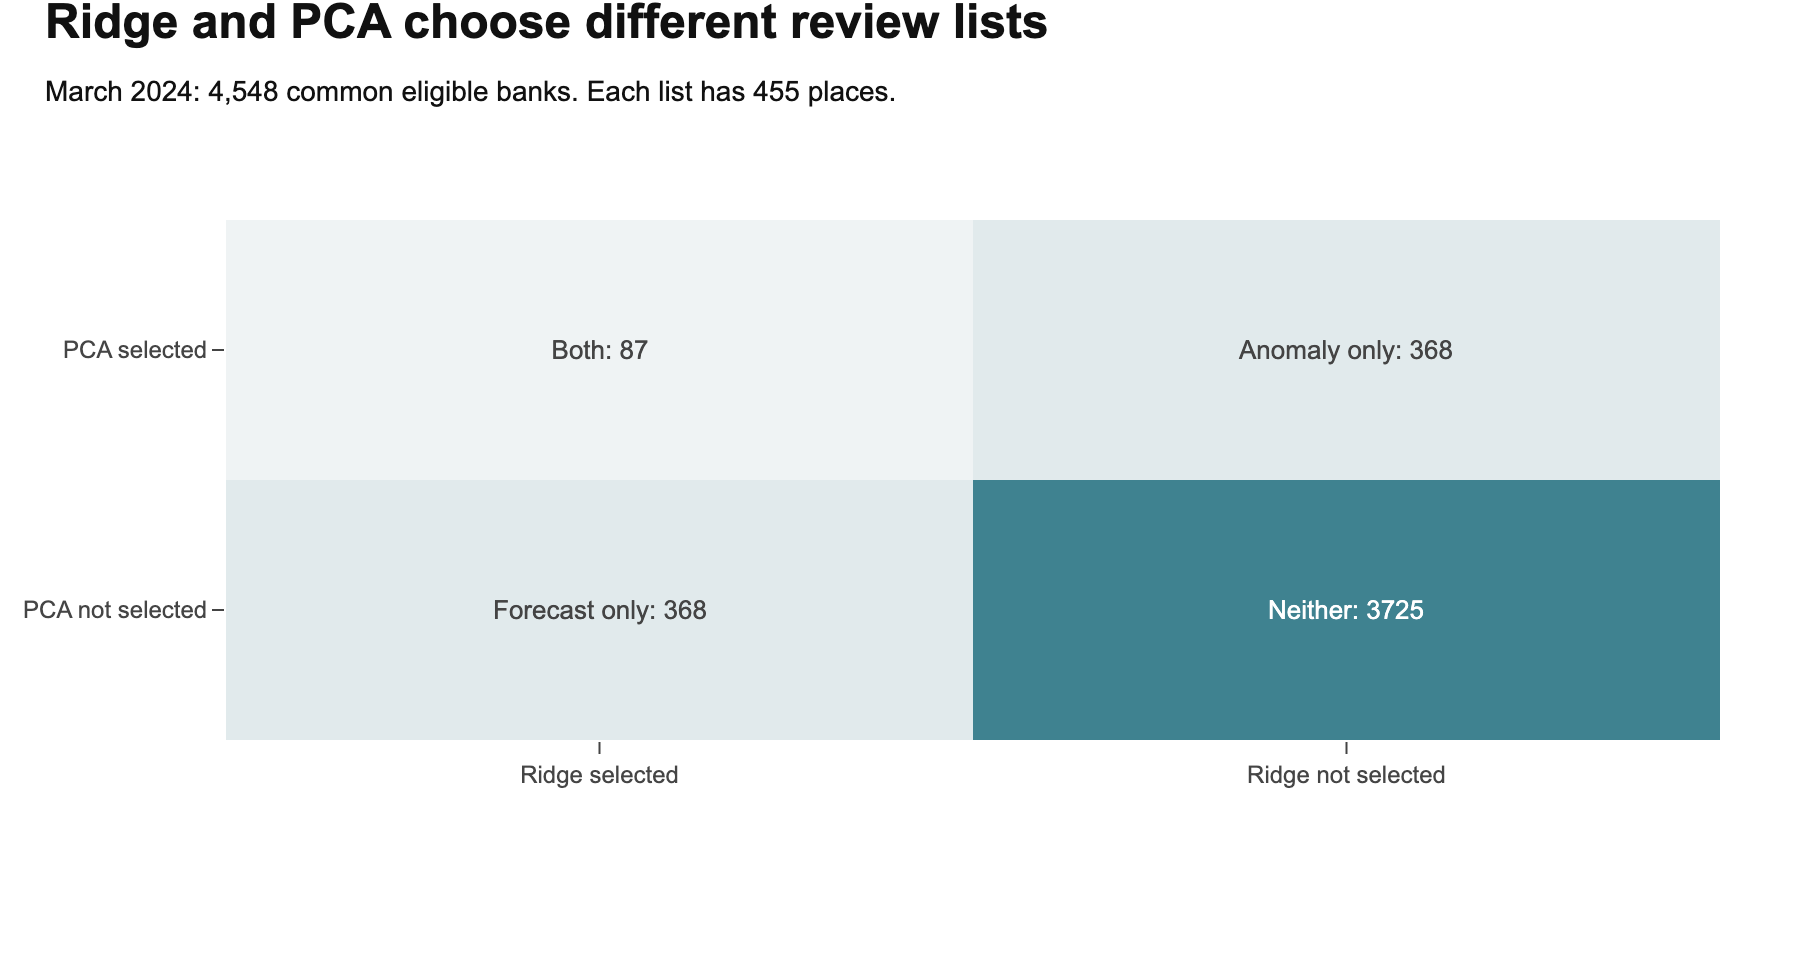

Group,Banks
Both,87
Forecast only,368
Anomaly only,368
Neither,3725



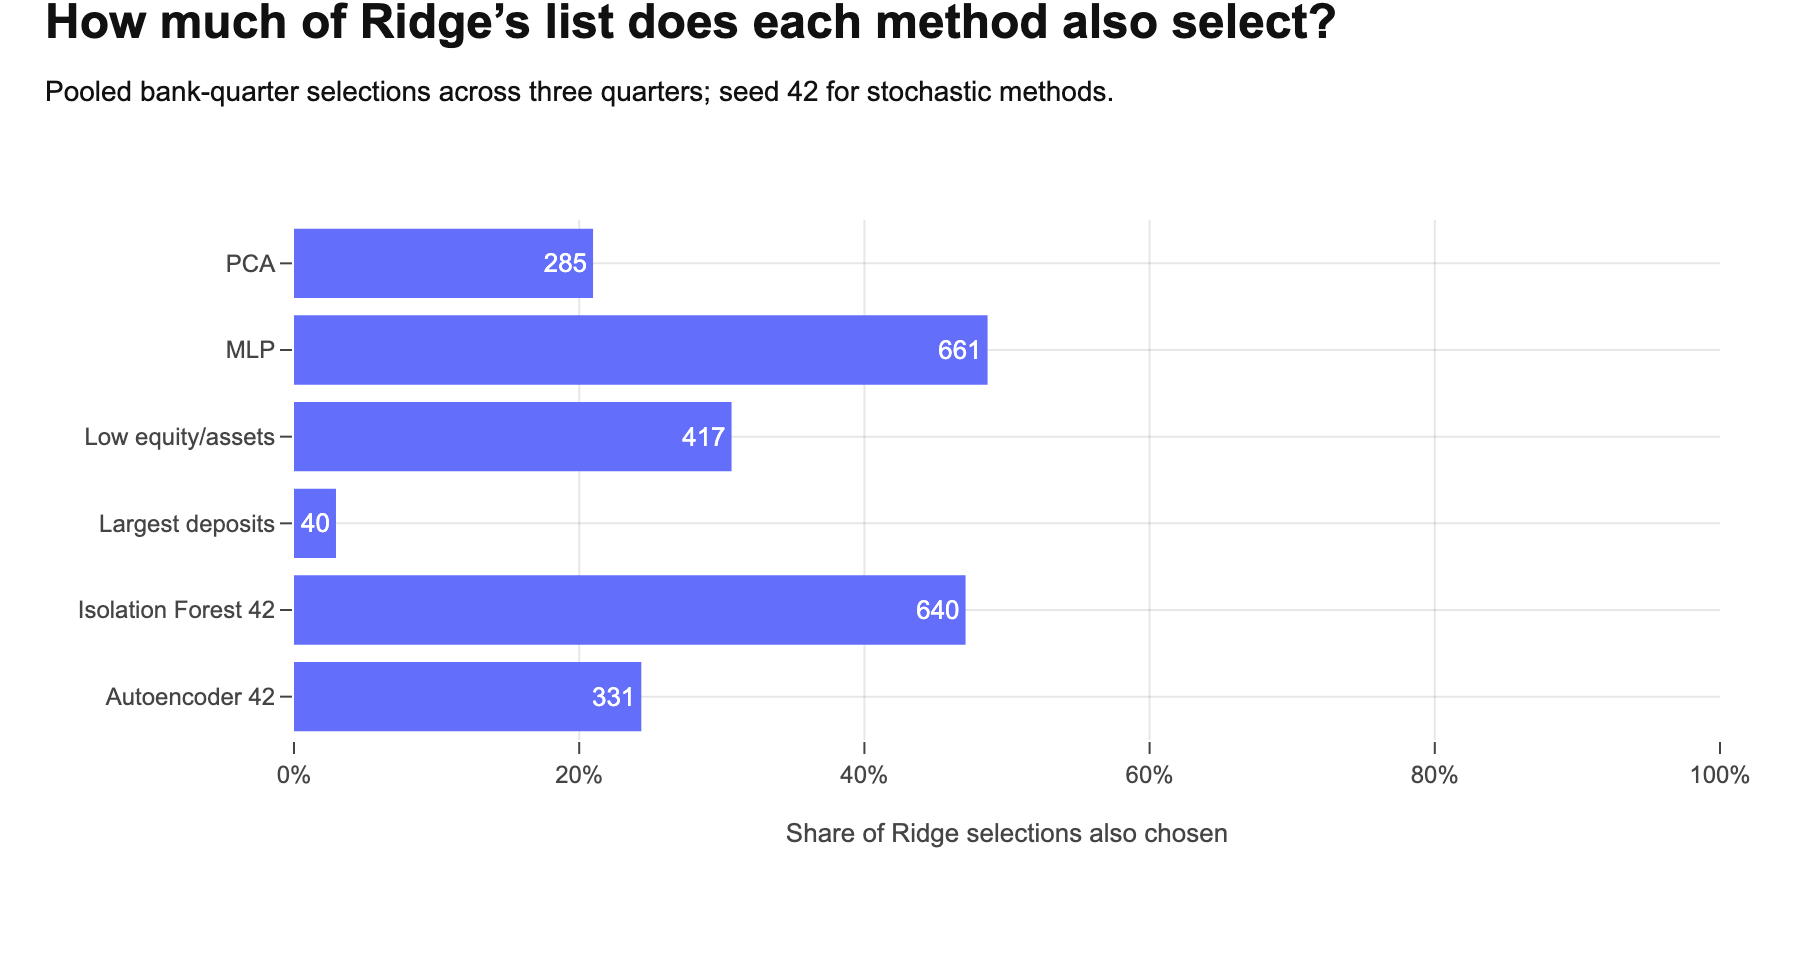

right,shared,left_count,left_share,jaccard,random_expected
Autoencoder 42,331,1359,24.4%,0.139,136.04
Isolation Forest 42,640,1359,47.1%,0.308,136.04
Largest deposits,40,1359,2.9%,0.015,136.04
Low equity/assets,417,1359,30.7%,0.181,136.04
MLP,661,1359,48.6%,0.321,136.04
PCA,285,1359,21.0%,0.117,136.04


In [13]:
# EXEMPLAR: missingness-evidence
selections = pd.read_csv(OUT / "expanded_selections.csv")
march = selections.loc[selections.date.eq("2024-03-31")]
four = pd.DataFrame(
    {
        "Group": ["Both", "Forecast only", "Anomaly only", "Neither"],
        "Banks": [
            int((march.Ridge & march.PCA).sum()),
            int((march.Ridge & ~march.PCA).sum()),
            int((~march.Ridge & march.PCA).sum()),
            int((~march.Ridge & ~march.PCA).sum()),
        ],
    }
)
fig = go.Figure(
    go.Heatmap(
        z=[[four.Banks.iloc[0], four.Banks.iloc[2]], [four.Banks.iloc[1], four.Banks.iloc[3]]],
        x=["Ridge selected", "Ridge not selected"],
        y=["PCA selected", "PCA not selected"],
        text=[
            ["Both: " + str(four.Banks.iloc[0]), "Anomaly only: " + str(four.Banks.iloc[2])],
            ["Forecast only: " + str(four.Banks.iloc[1]), "Neither: " + str(four.Banks.iloc[3])],
        ],
        texttemplate="%{text}",
        colorscale=[[0, "#EFF3F4"], [1, "#3F8290"]],
        showscale=False,
    )
)
fig.update_yaxes(autorange="reversed")
chart(
    fig,
    "four_groups",
    "Ridge and PCA choose different review lists",
    f"March 2024: {len(march):,} common eligible banks. Each list has {int(march.Ridge.sum()):,} places.",
)
table(four, "Each bank appears in exactly one group")
overlap = pd.read_csv(OUT / "expanded_overlap.csv")
primary = [
    "MLP",
    "Low equity/assets",
    "Largest deposits",
    "PCA",
    "Isolation Forest 42",
    "Autoencoder 42",
]
shown = overlap.loc[
    overlap.date.eq("All three quarters") & overlap.left.eq("Ridge") & overlap.right.isin(primary)
]
fig = px.bar(shown, x="left_share", y="right", orientation="h", text="shared")
fig.update_xaxes(title="Share of Ridge selections also chosen", tickformat=".0%", range=[0, 1])
fig.update_yaxes(title="")
chart(
    fig,
    "ridge_overlap",
    "How much of Ridge’s list does each method also select?",
    "Pooled bank-quarter selections across three quarters; seed 42 for stochastic methods.",
)
table(
    shown[["right", "shared", "left_count", "left_share", "jaccard", "random_expected"]],
    "Shared selections and independent-random expectation",
    {"left_share": "{:.1%}", "jaccard": "{:.3f}", "random_expected": "{:.2f}"},
)

## What did each method select?

Choose the shared bank with the highest PCA score, the forecast-only bank with the lowest Ridge forecast, and the anomaly-only bank with the highest PCA score. These rules were fixed before inspecting the bank names. The examples explain these selections; they do not represent every bank in their group.

group,CERT,NAME
Both,27330,SILVERGATE BANK
Forecast only,27010,YOUNG AMERICANS BANK
Anomaly only,57083,EMIGRANT BANK



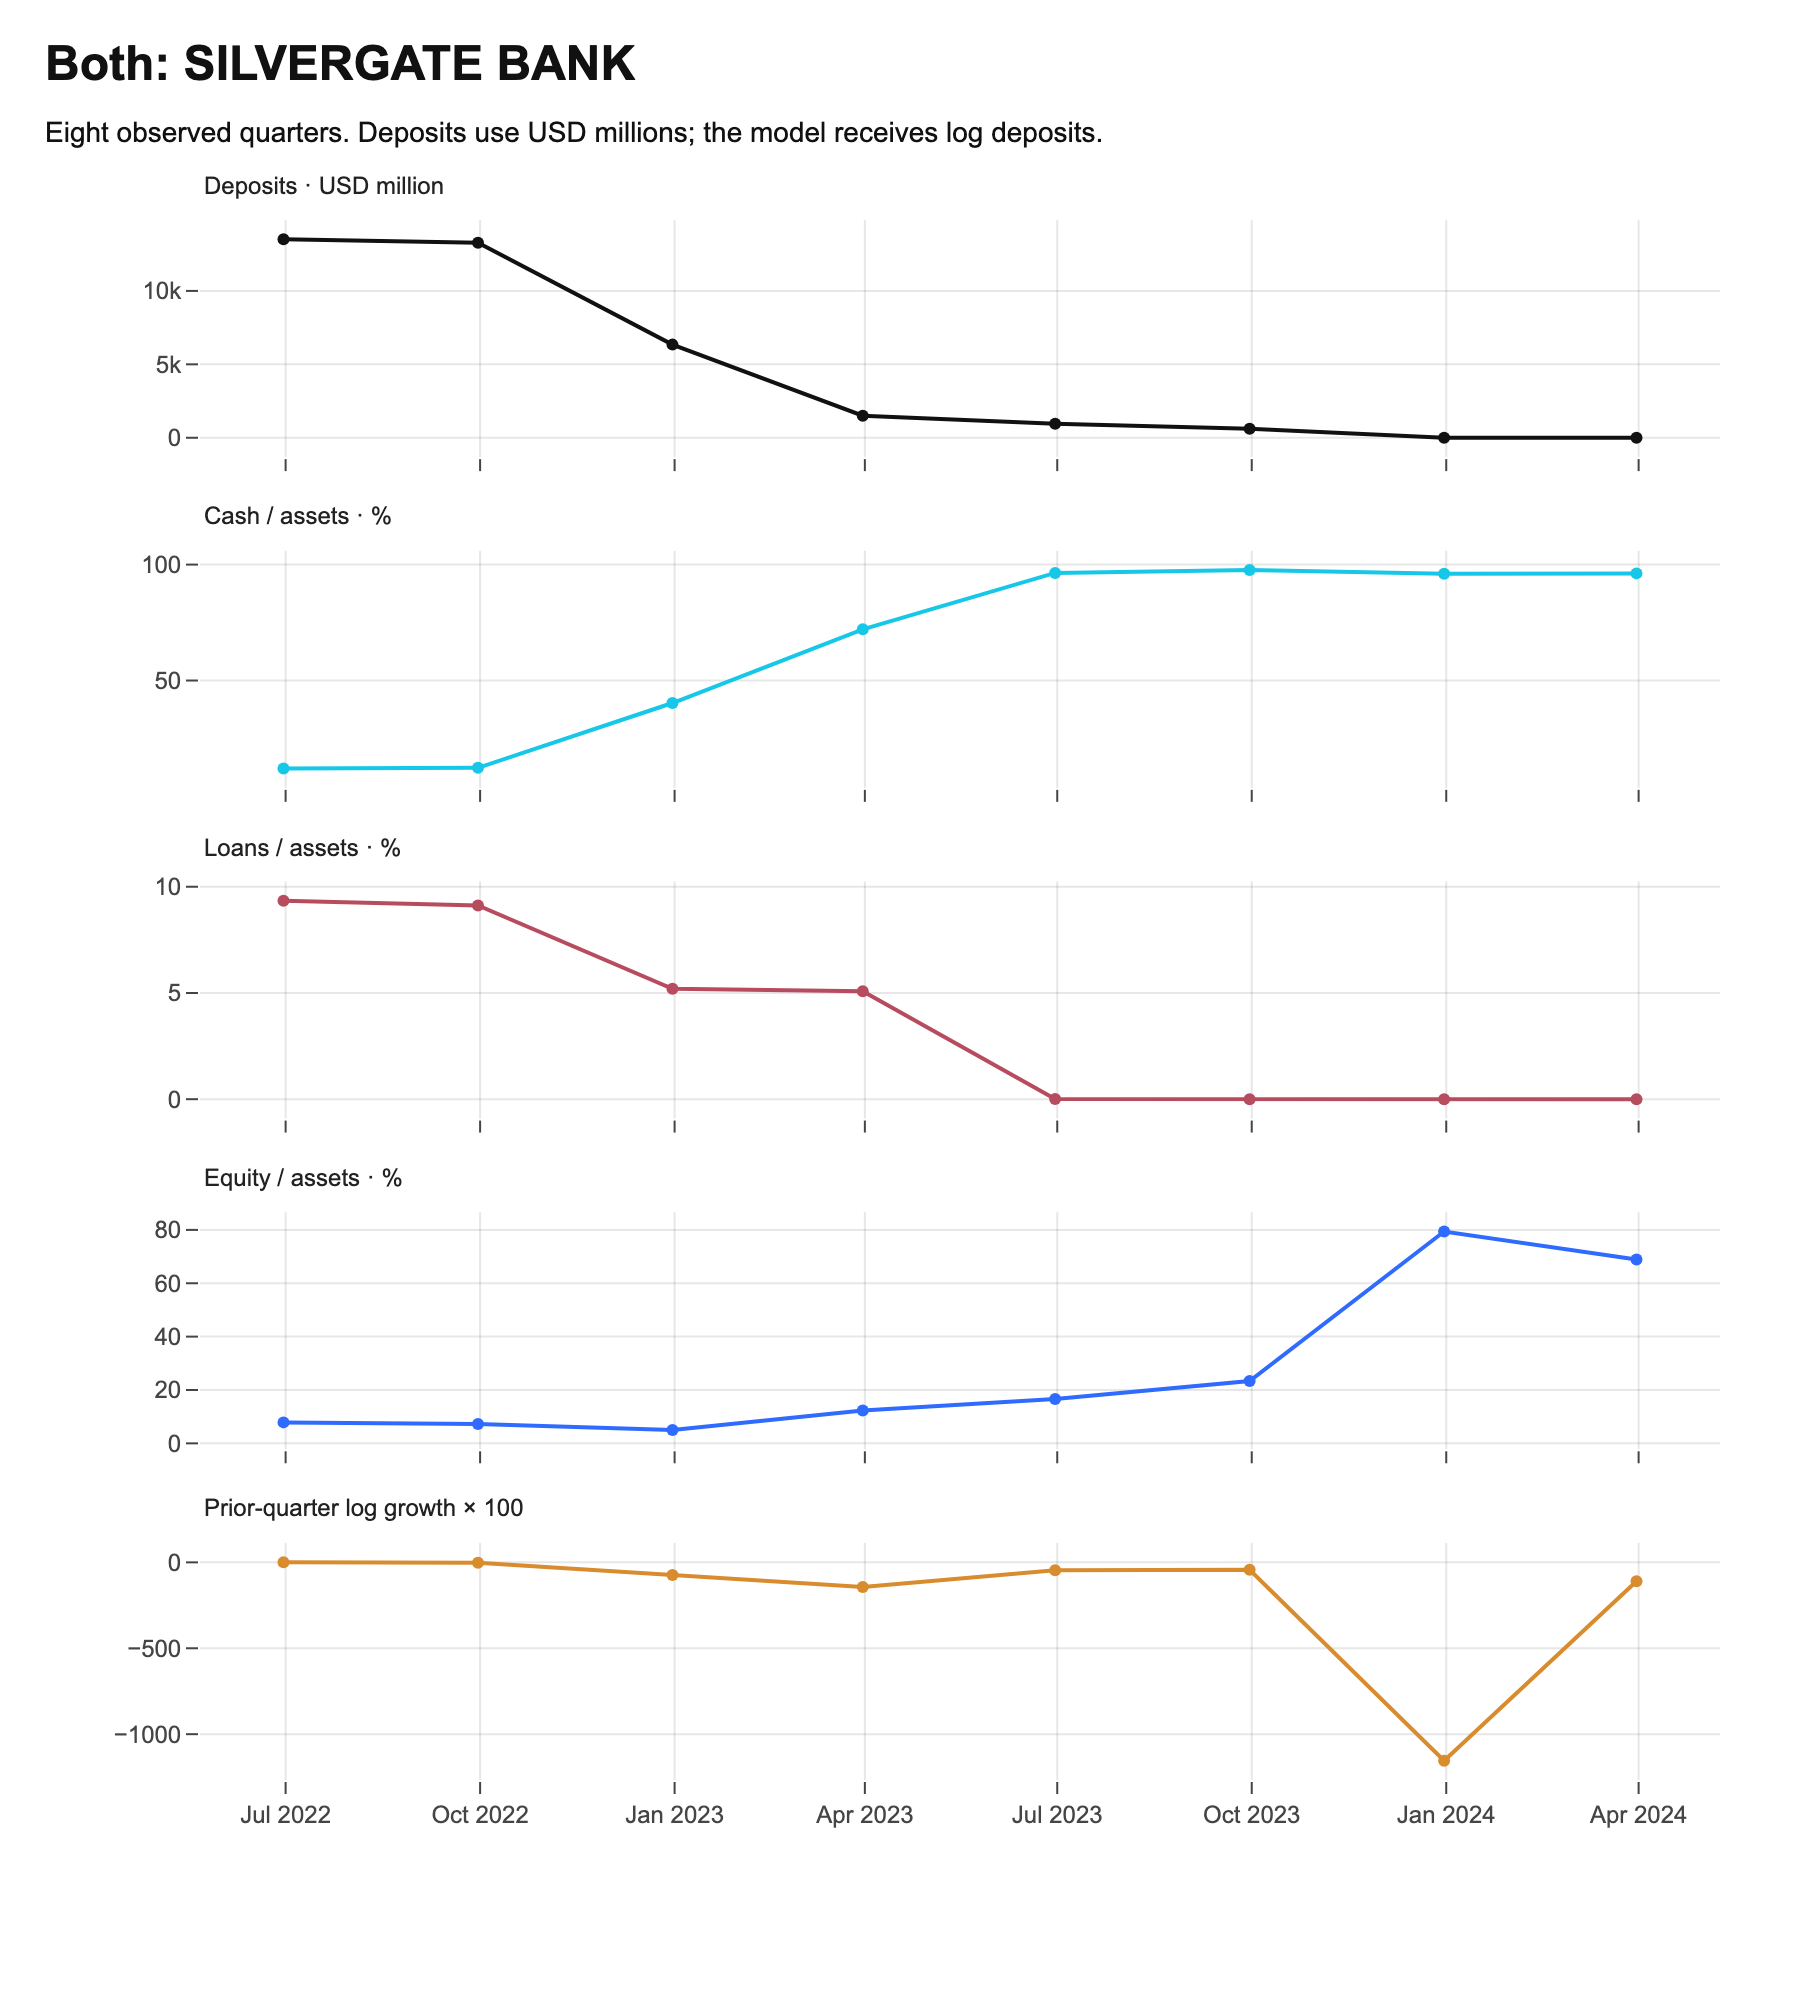


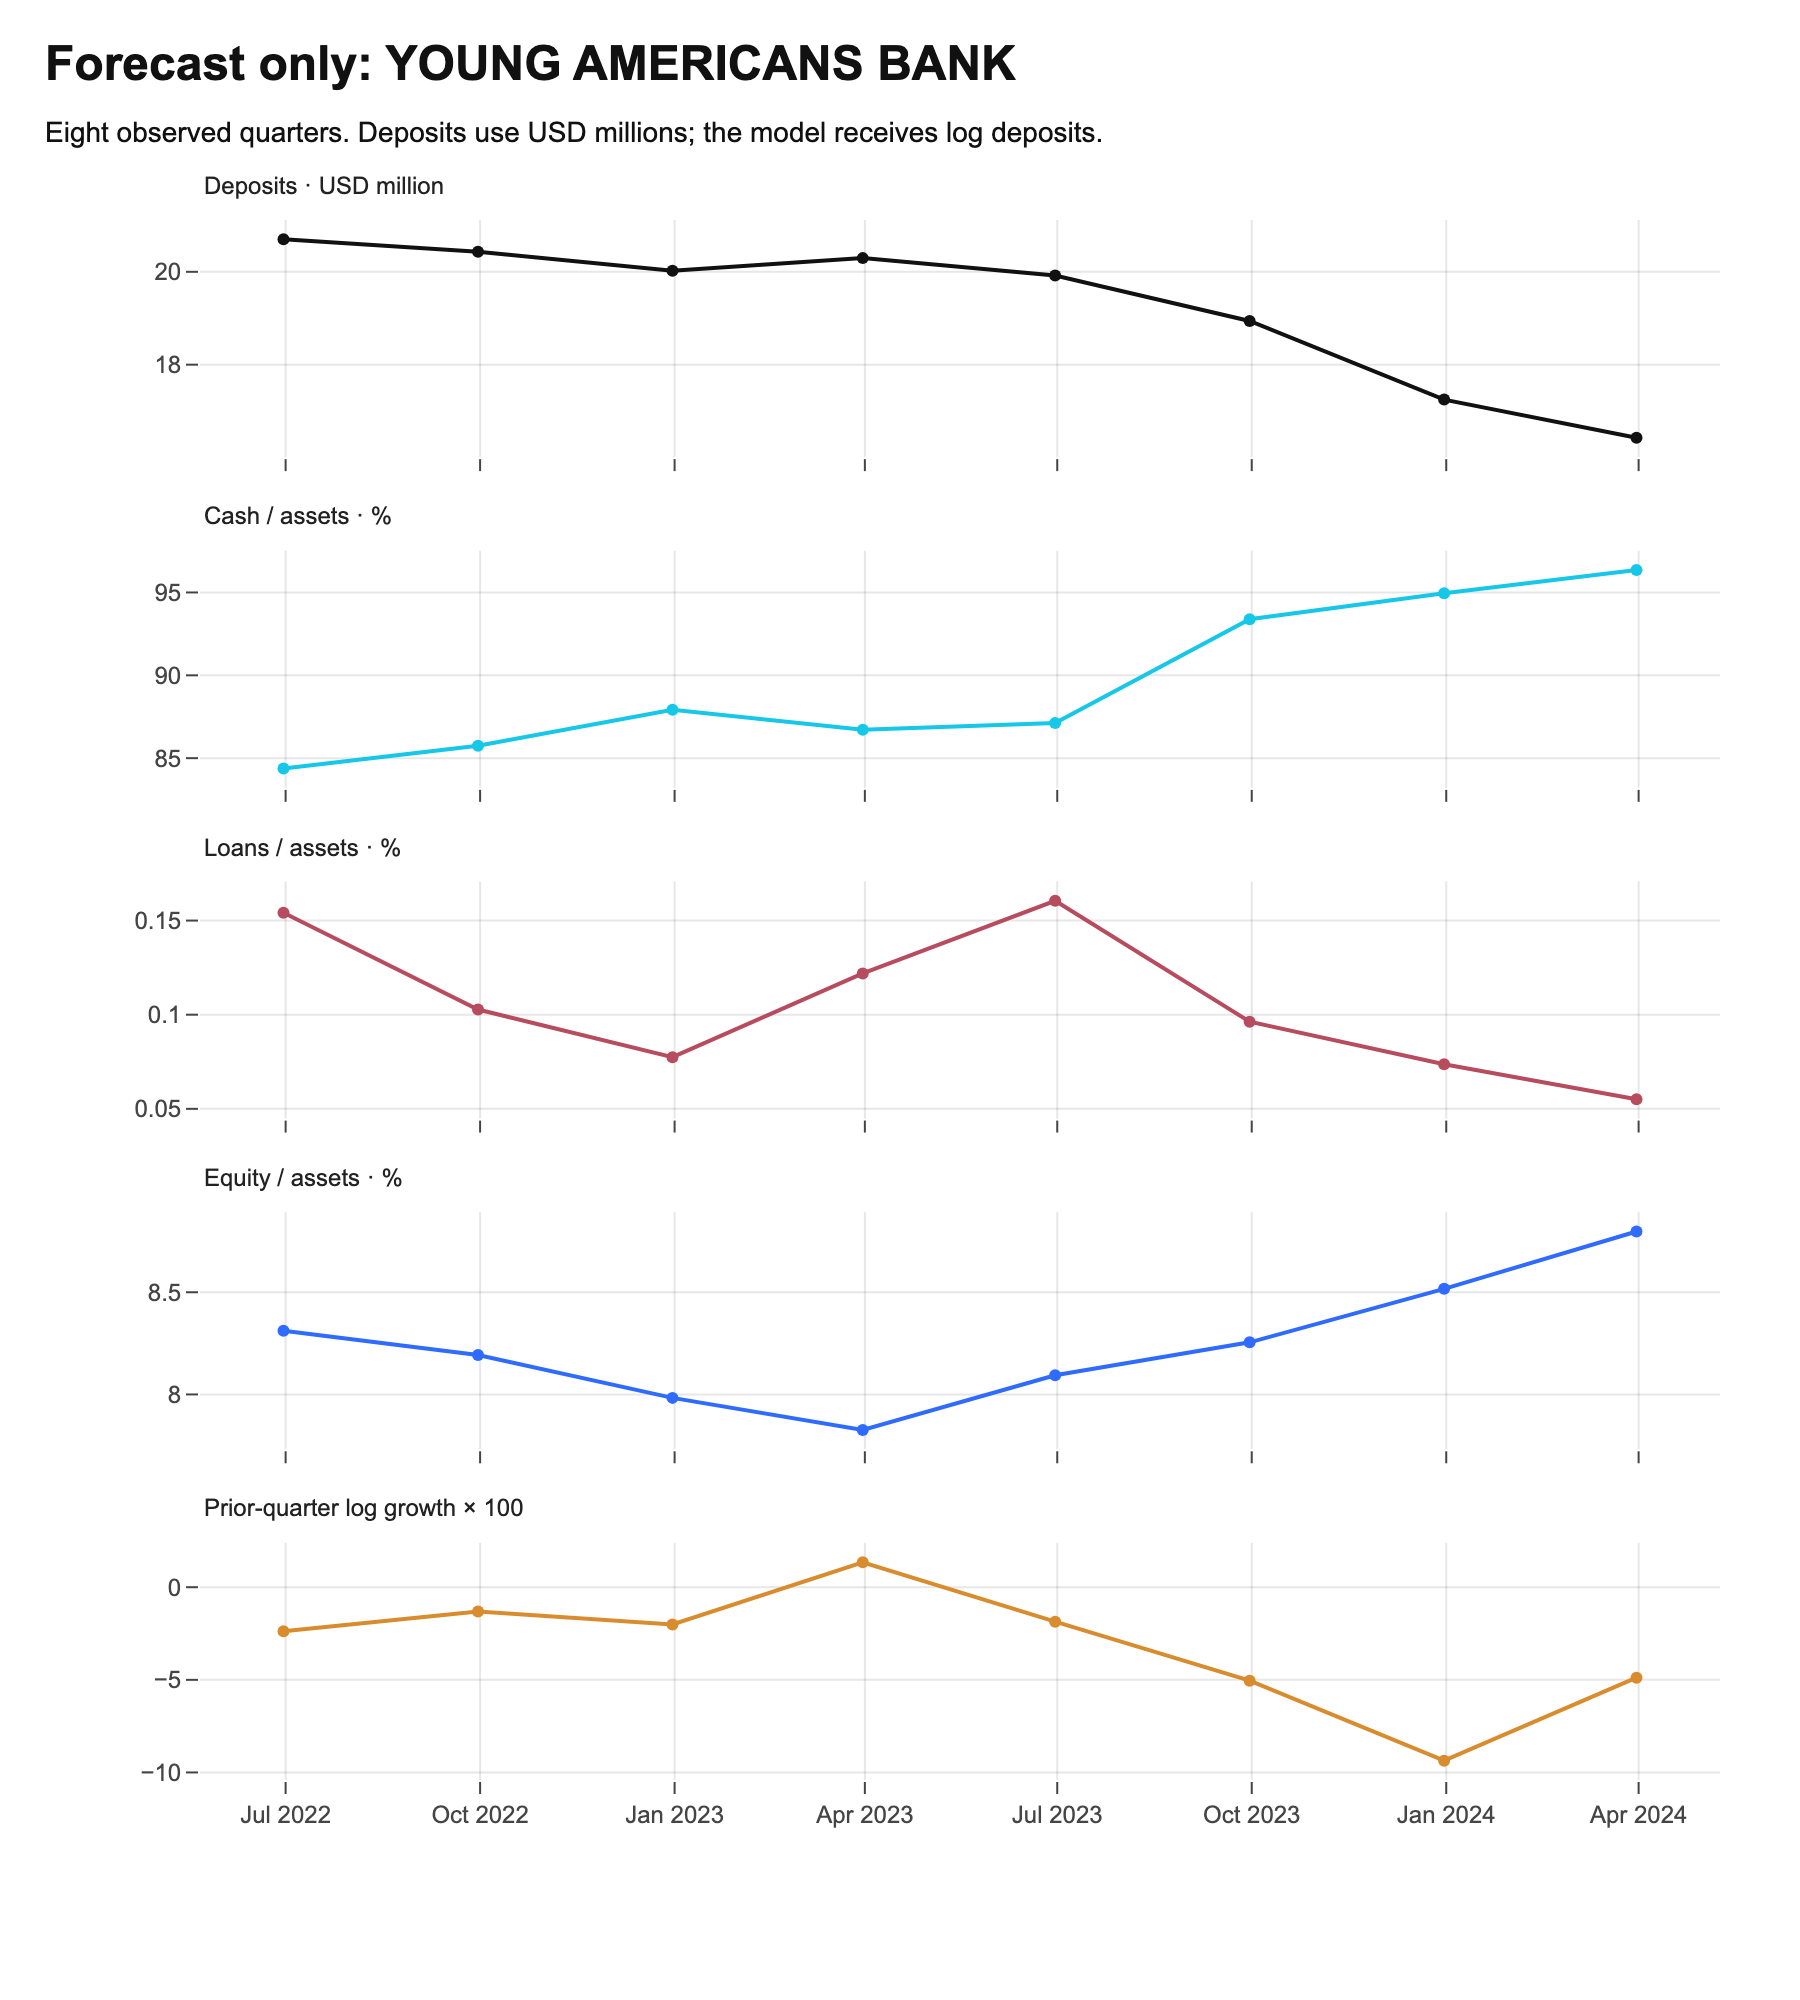


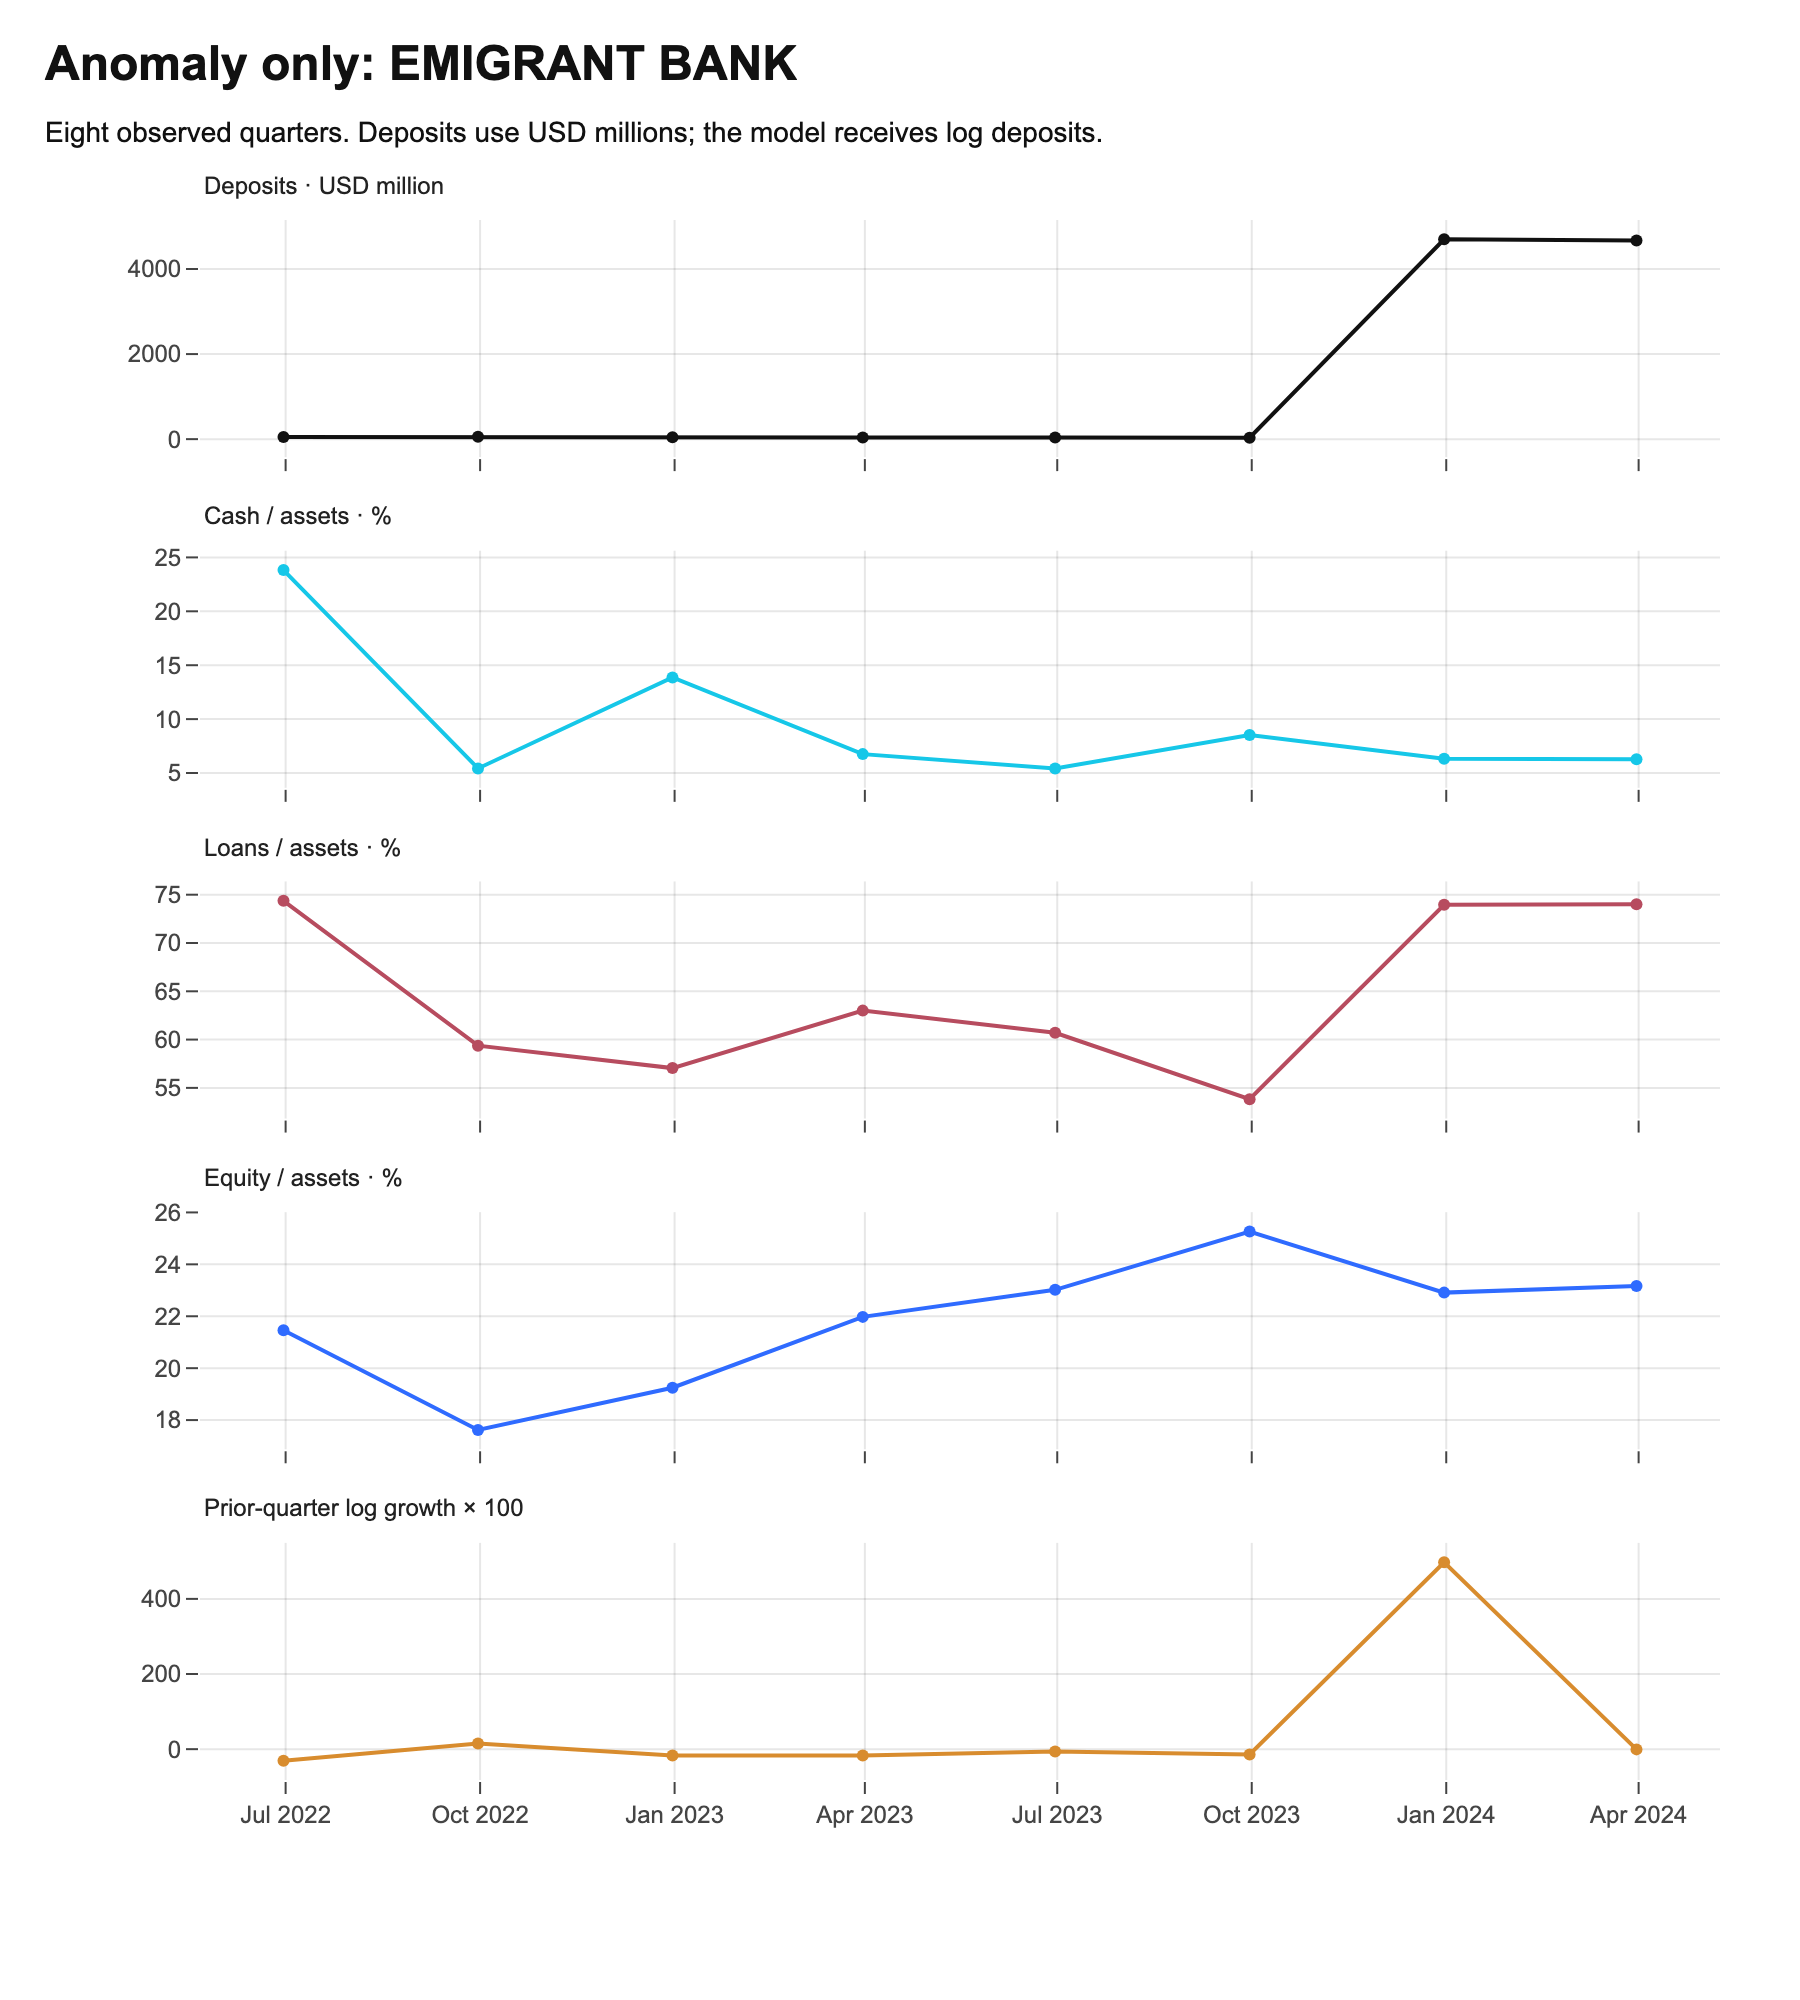


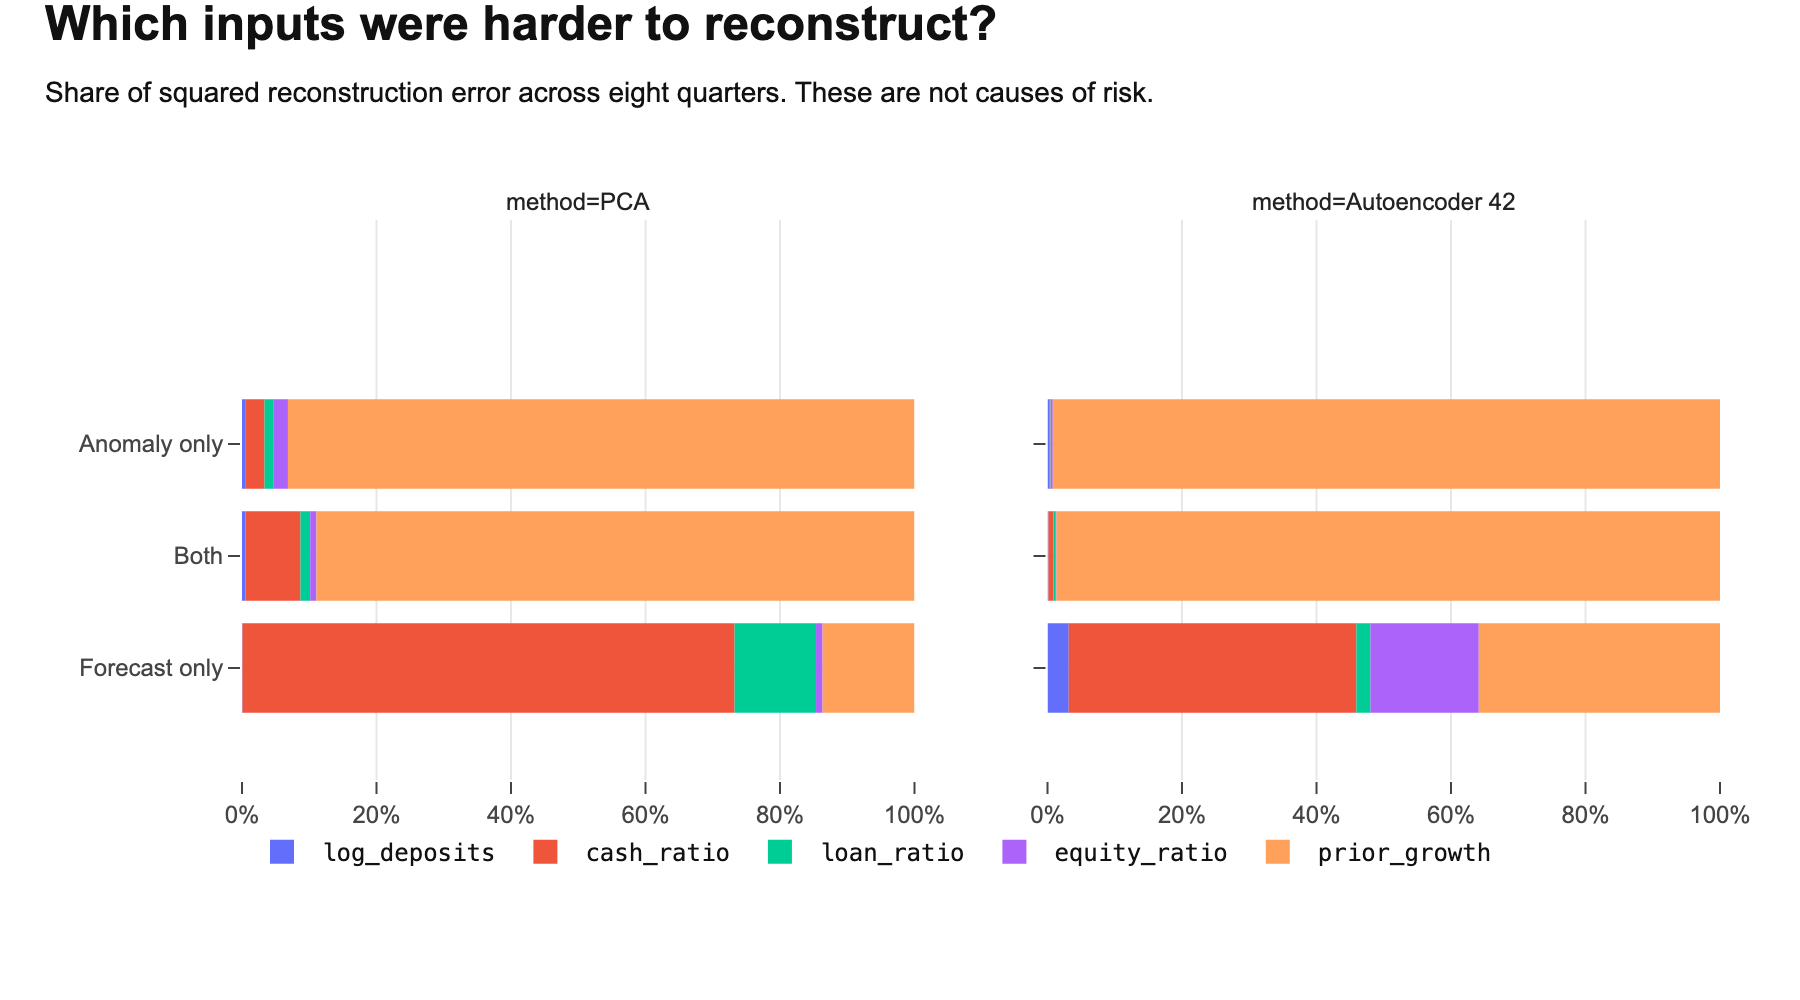

group,method,log_deposits,cash_ratio,loan_ratio,equity_ratio,prior_growth
Forecast only,PCA,0.1%,73.2%,12.1%,1.0%,13.7%
Both,PCA,0.5%,8.2%,1.4%,0.9%,88.9%
Anomaly only,PCA,0.6%,2.8%,1.3%,2.2%,93.2%
Forecast only,Autoencoder 42,3.2%,42.8%,2.1%,16.1%,35.9%
Both,Autoencoder 42,0.1%,0.7%,0.3%,0.2%,98.7%
Anomaly only,Autoencoder 42,0.3%,0.1%,0.1%,0.3%,99.2%


In [14]:
examples = pd.read_csv(OUT / "examples.csv")
table(examples, "Three examples selected by the declared rules")
histories = pd.read_csv(OUT / "example_histories.csv", parse_dates=["date"])
labels = {
    "DEPDOM": "Deposits · USD million",
    "cash_ratio": "Cash / assets · %",
    "loan_ratio": "Loans / assets · %",
    "equity_ratio": "Equity / assets · %",
    "prior_growth": "Prior-quarter log growth × 100",
}
for example in examples.dropna(subset=["CERT"]).itertuples(index=False):
    bank = histories.loc[histories.CERT.eq(example.CERT)]
    fig = make_subplots(rows=5, cols=1, shared_xaxes=True, vertical_spacing=0.06)
    for position, (feature, label) in enumerate(labels.items(), start=1):
        values = bank[feature] / 1000 if feature == "DEPDOM" else bank[feature] * 100
        fig.add_trace(
            go.Scatter(x=bank.date, y=values, mode="lines+markers", name=label, showlegend=False),
            row=position,
            col=1,
        )
        fig.update_yaxes(title="", row=position, col=1)
        axis = "" if position == 1 else str(position)
        fig.add_annotation(
            x=0,
            y=1,
            xref="x" + axis + " domain",
            yref="y" + axis + " domain",
            text=label,
            showarrow=False,
            xanchor="left",
            yanchor="bottom",
            yshift=8,
        )
    chart(
        fig,
        "history_" + str(int(example.CERT)),
        example.group + ": " + example.NAME,
        "Eight observed quarters. Deposits use USD millions; the model receives log deposits.",
        height=1000,
    )
shares = pd.read_csv(OUT / "reconstruction_shares.csv")
case_shares = shares.merge(examples[["CERT", "group"]], on="CERT").loc[
    lambda f: f.date.eq("2024-03-31")
]
long = case_shares.melt(
    id_vars=["group", "method"], value_vars=list(FEATURES), var_name="Input", value_name="Share"
)
fig = px.bar(
    long,
    x="Share",
    y="group",
    color="Input",
    facet_col="method",
    facet_col_spacing=0.09,
    orientation="h",
)
fig.update_xaxes(tickformat=".0%", range=[0, 1], title="")
fig.update_yaxes(title="")
chart(
    fig,
    "reconstruction_shares",
    "Which inputs were harder to reconstruct?",
    "Share of squared reconstruction error across eight quarters. These are not causes of risk.",
    height=500,
)
table(
    case_shares[["group", "method", *FEATURES]],
    "Exact reconstruction-error shares",
    {feature: "{:.1%}" for feature in FEATURES},
)

## Did the models mostly react to deposit size?

Remove `log_deposits` and repeat the learned methods on the same banks and dates. Other inputs can still correlate with size. Here we check dependence on the explicit size feature.


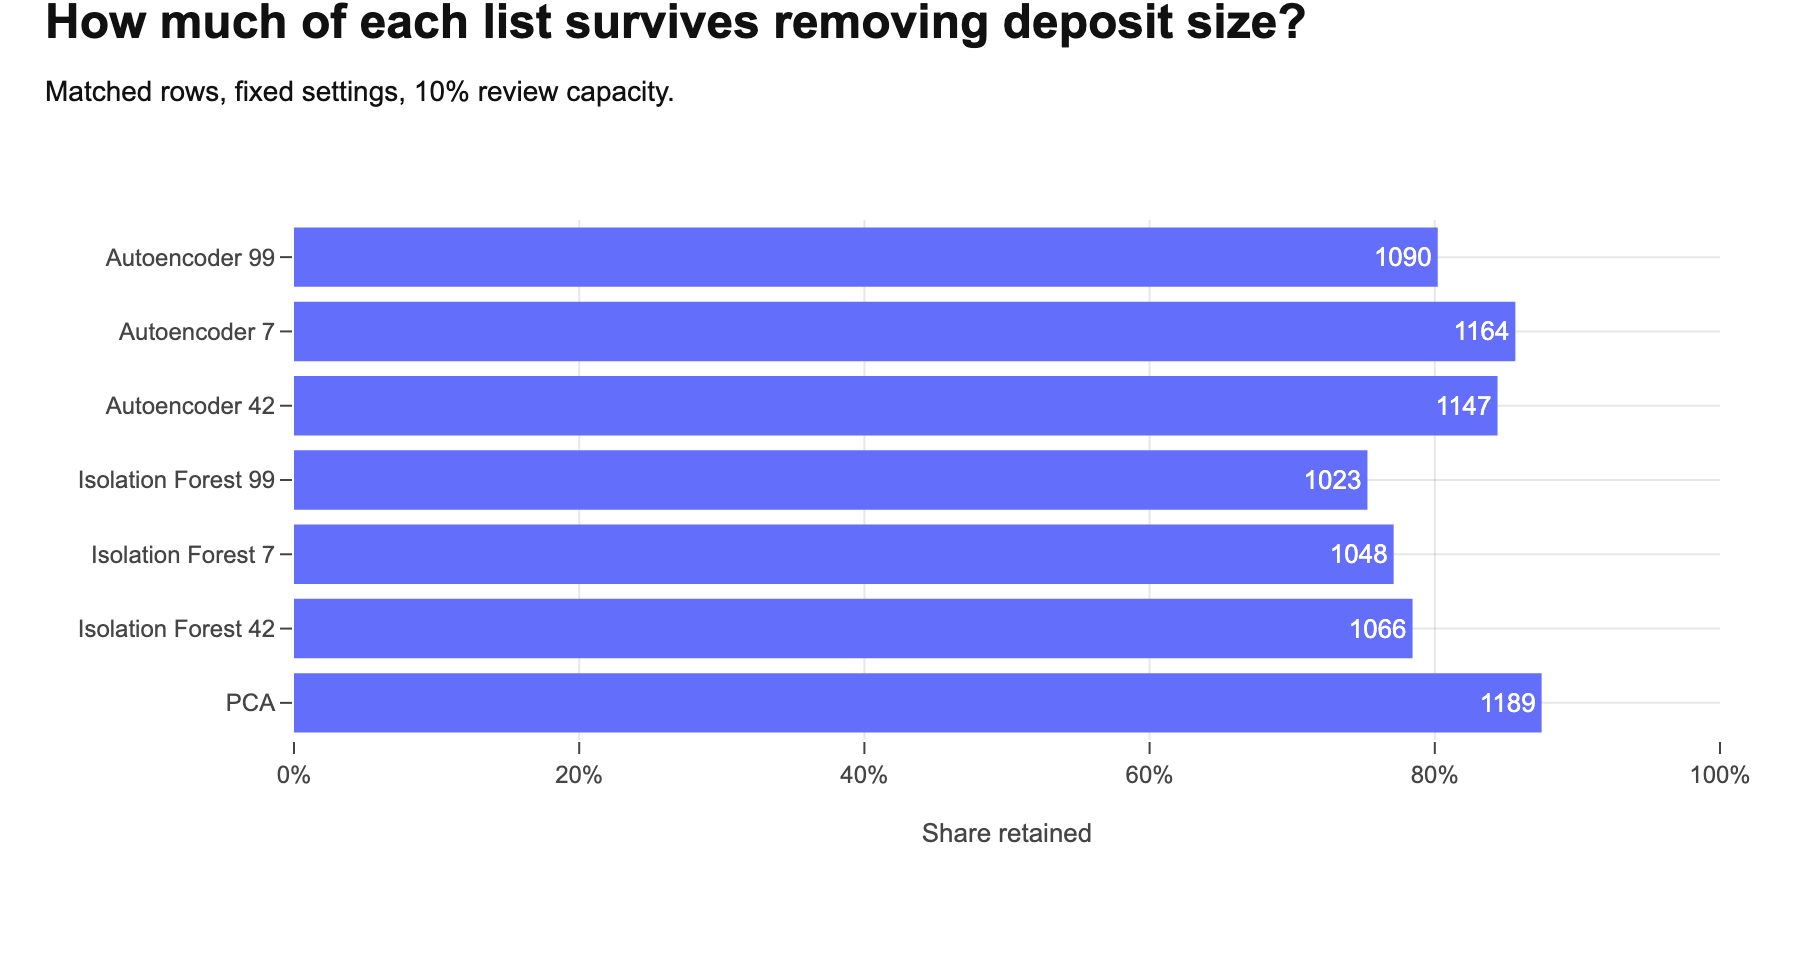

Method,Shared selections,Share retained,Jaccard
PCA,1189,87.5%,0.778
Isolation Forest 42,1066,78.4%,0.645
Isolation Forest 7,1048,77.1%,0.628
Isolation Forest 99,1023,75.3%,0.604
Autoencoder 42,1147,84.4%,0.730
Autoencoder 7,1164,85.7%,0.749
Autoencoder 99,1090,80.2%,0.670


In [15]:
pairs = []
for method in [
    "PCA",
    "Isolation Forest 42",
    "Isolation Forest 7",
    "Isolation Forest 99",
    "Autoencoder 42",
    "Autoencoder 7",
    "Autoencoder 99",
]:
    row = overlap.loc[
        overlap.date.eq("All three quarters")
        & (
            ((overlap.left == method) & (overlap.right == method + " without size"))
            | ((overlap.right == method) & (overlap.left == method + " without size"))
        )
    ].iloc[0]
    pairs.append(
        {
            "Method": method,
            "Shared selections": int(row.shared),
            "Share retained": row.left_share,
            "Jaccard": row.jaccard,
        }
    )
size_check = pd.DataFrame(pairs)
fig = px.bar(size_check, x="Share retained", y="Method", orientation="h", text="Shared selections")
fig.update_xaxes(range=[0, 1], tickformat=".0%")
fig.update_yaxes(title="")
chart(
    fig,
    "size_check",
    "How much of each list survives removing deposit size?",
    "Matched rows, fixed settings, 10% review capacity.",
)
table(
    size_check,
    "Full-input versus no-deposit-size lists",
    {"Share retained": "{:.1%}", "Jaccard": "{:.3f}"},
)

## Does a different seed change who gets reviewed?

Use every pair among seeds 42, 7, and 99. Agreement between seeds concerns repeatability of the list; it does not establish that the list serves the review objective.


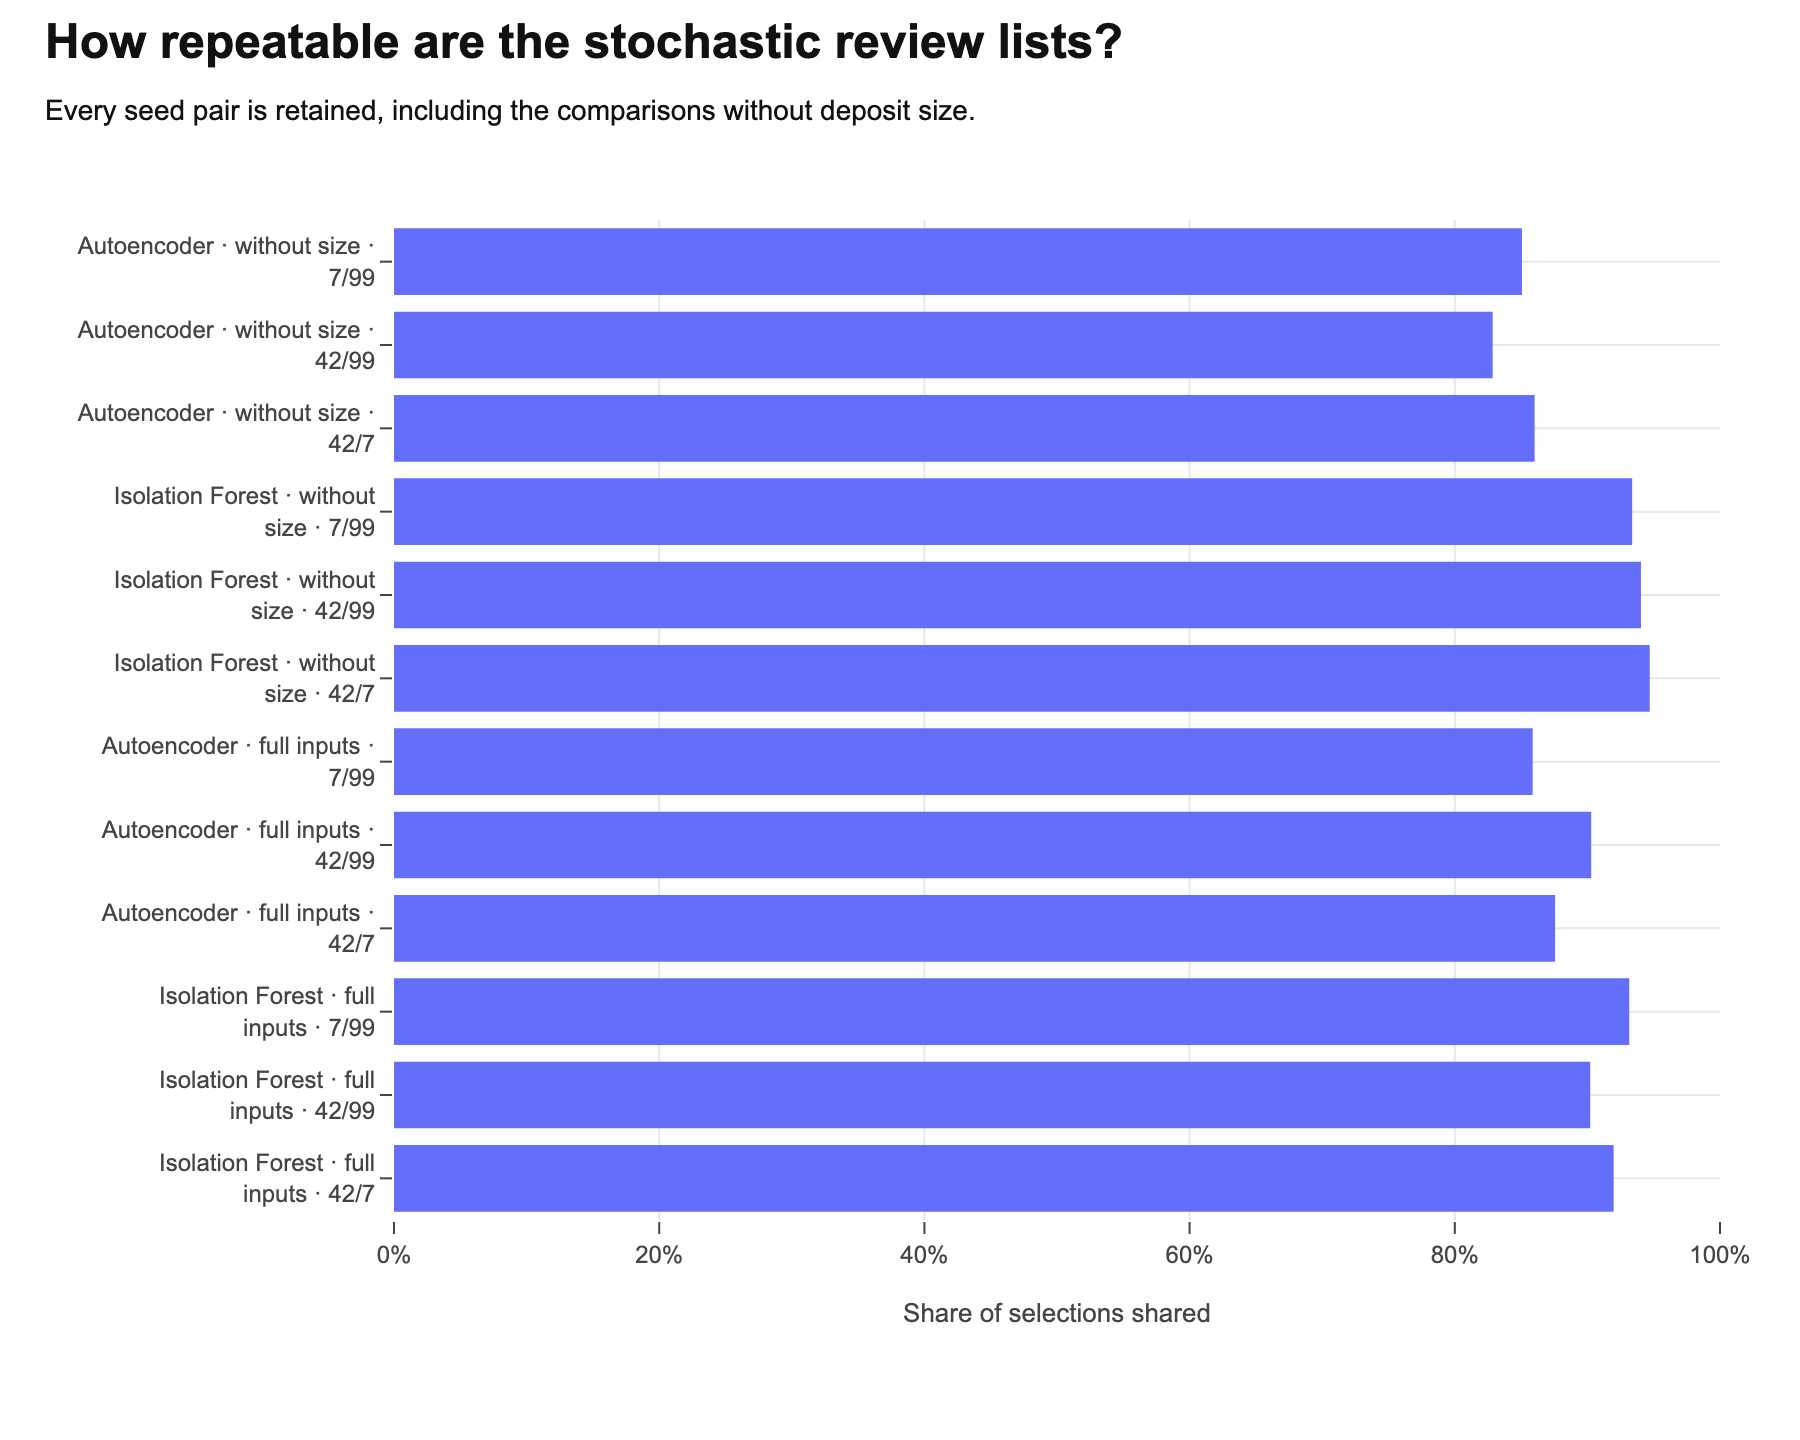

left,right,shared,left_count,left_share,jaccard
Isolation Forest 42,Isolation Forest 7,1250,1359,92.0%,0.851
Isolation Forest 42,Isolation Forest 99,1226,1359,90.2%,0.822
Isolation Forest 7,Isolation Forest 99,1266,1359,93.2%,0.872
Autoencoder 42,Autoencoder 7,1190,1359,87.6%,0.779
Autoencoder 42,Autoencoder 99,1227,1359,90.3%,0.823
Autoencoder 7,Autoencoder 99,1167,1359,85.9%,0.752
Isolation Forest 42 without size,Isolation Forest 7 without size,1287,1359,94.7%,0.899
Isolation Forest 42 without size,Isolation Forest 99 without size,1278,1359,94.0%,0.887
Isolation Forest 7 without size,Isolation Forest 99 without size,1269,1359,93.4%,0.876
Autoencoder 42 without size,Autoencoder 7 without size,1169,1359,86.0%,0.755


In [16]:
stable = []
for representation in ["", " without size"]:
    for family in ["Isolation Forest", "Autoencoder"]:
        methods = [f"{family} {seed}" + representation for seed in [42, 7, 99]]
        part = overlap.loc[
            overlap.date.eq("All three quarters")
            & overlap.left.isin(methods)
            & overlap.right.isin(methods)
        ].copy()
        version = "without size" if representation else "full inputs"
        part["Comparison"] = [
            family
            + " · "
            + version
            + " · "
            + a.split()[1 if family == "Autoencoder" else 2]
            + "/"
            + b.split()[1 if family == "Autoencoder" else 2]
            for a, b in zip(part.left, part.right)
        ]
        stable.append(part)
stability = pd.concat(stable)
fig = px.bar(stability, x="left_share", y="Comparison", orientation="h")
fig.update_xaxes(range=[0, 1], tickformat=".0%", title="Share of selections shared")
fig.update_yaxes(title="")
chart(
    fig,
    "seed_stability",
    "How repeatable are the stochastic review lists?",
    "Every seed pair is retained, including the comparisons without deposit size.",
    height=720,
)
table(
    stability[["left", "right", "shared", "left_count", "left_share", "jaccard"]],
    "Exact seed overlap",
    {"left_share": "{:.1%}", "jaccard": "{:.3f}"},
)

## Which lists captured more of the low-growth outcomes?

Now use the original common-history population with observed outcomes. Recalculate every list and the realized lowest-growth decile on that same population. These are new matched-population results; the original Study 1 lists remain unchanged.

This checks the deposit-growth objective we started with. An unusual history can have other explanations or uses that this outcome does not measure.

In [17]:
def outcome_capture(rows, flags):
    """Evaluate the same quarter-specific realized bottom decile for every list."""
    if not np.isfinite(rows.growth).all():
        raise ValueError("Observed outcomes are required for this comparison")
    records = []
    for date, quarter in rows.groupby("date"):
        k = int(np.ceil(0.10 * len(quarter)))
        target = quarter.sort_values(["growth", "CERT"]).head(k).index
        for method in flags.columns:
            chosen = flags.loc[quarter.index, method]
            hits = int(flags.loc[target, method].sum())
            records.append(
                {
                    "date": str(date.date()),
                    "method": method,
                    "eligible": len(quarter),
                    "selected": int(chosen.sum()),
                    "target_count": k,
                    "captured": hits,
                    "capture_per_selected": hits / chosen.sum(),
                }
            )
    result = pd.DataFrame(records)
    total = (
        result.groupby("method")[["eligible", "selected", "target_count", "captured"]]
        .sum()
        .reset_index()
    )
    total["date"] = "All three quarters"
    total["capture_per_selected"] = total.captured / total.selected
    return pd.concat([result, total], ignore_index=True)


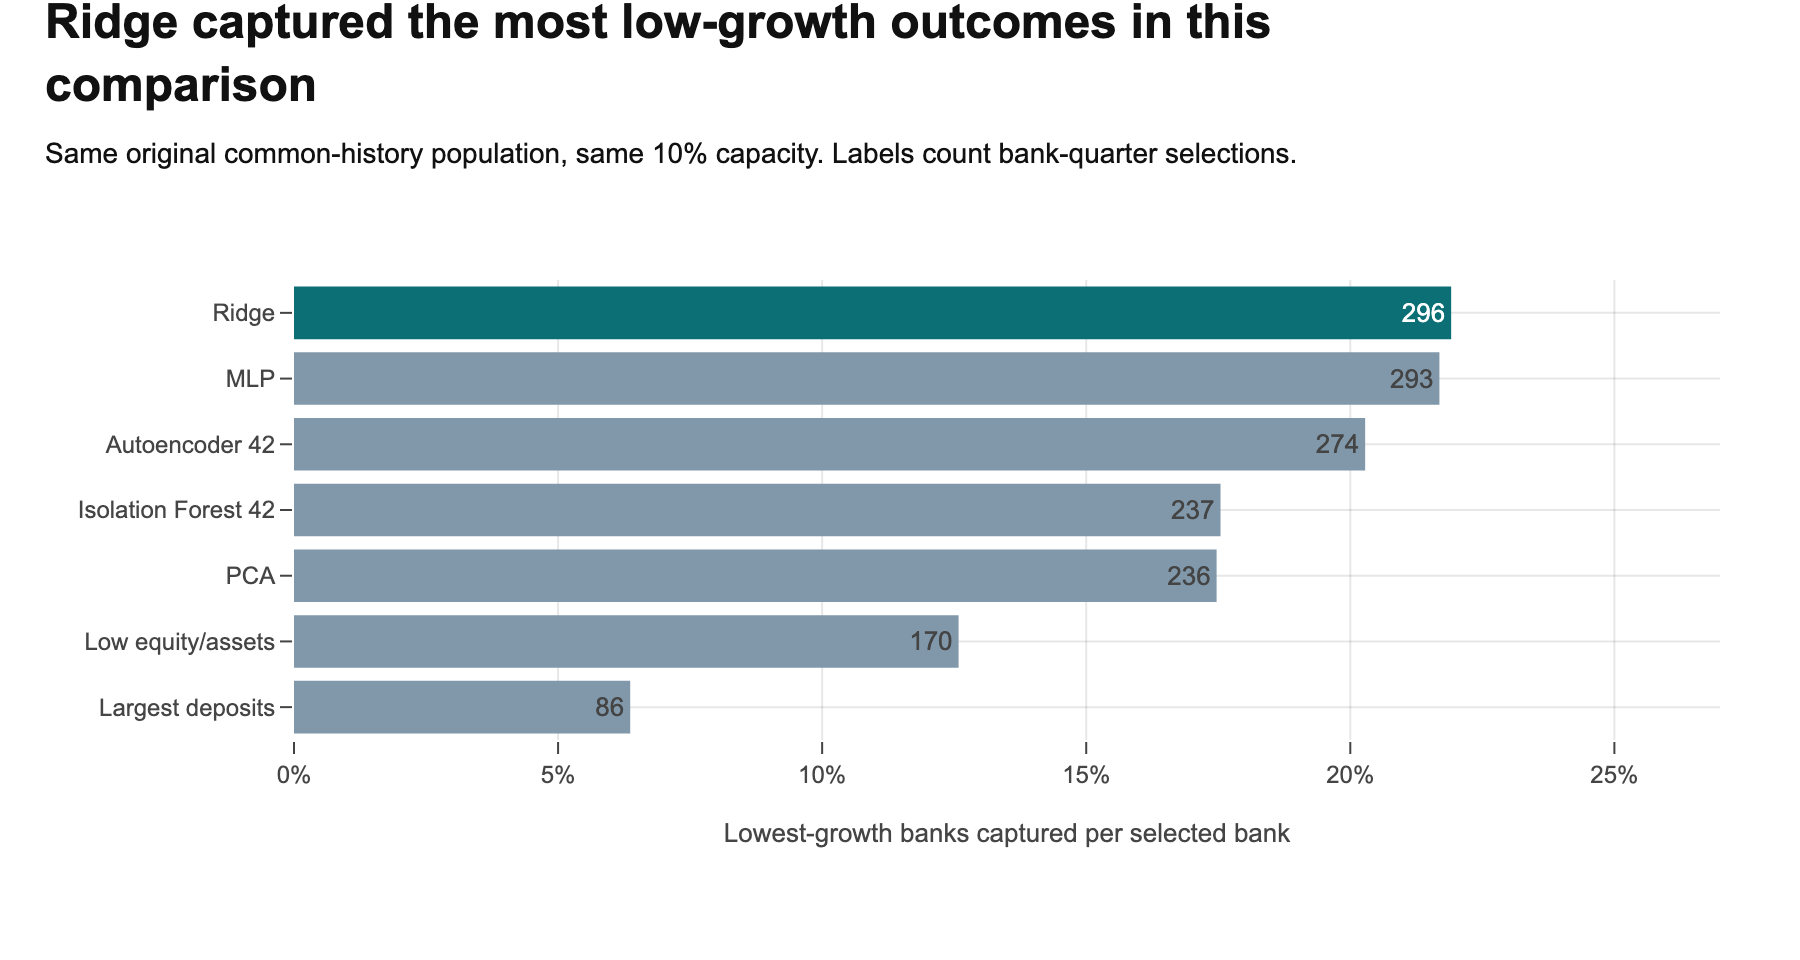

method,captured,selected,capture_per_selected
Largest deposits,86,1351,6.4%
Low equity/assets,170,1351,12.6%
PCA,236,1351,17.5%
Isolation Forest 42,237,1351,17.5%
Autoencoder 42,274,1351,20.3%
MLP,293,1351,21.7%
Ridge,296,1351,21.9%


date,method,eligible,selected,target_count,captured,capture_per_selected
2024-03-31,Ridge,4518,452,452,111,24.6%
2024-03-31,MLP,4518,452,452,107,23.7%
2024-03-31,Low equity/assets,4518,452,452,52,11.5%
2024-03-31,Largest deposits,4518,452,452,28,6.2%
2024-03-31,PCA,4518,452,452,84,18.6%
2024-03-31,Isolation Forest 42,4518,452,452,87,19.2%
2024-03-31,Isolation Forest 7,4518,452,452,82,18.1%
2024-03-31,Isolation Forest 99,4518,452,452,84,18.6%
2024-03-31,Autoencoder 42,4518,452,452,99,21.9%
2024-03-31,Autoencoder 7,4518,452,452,94,20.8%


In [18]:
capture = pd.read_csv(OUT / "outcome_capture.csv")
main_methods = [
    "Ridge",
    "MLP",
    "Low equity/assets",
    "Largest deposits",
    "PCA",
    "Isolation Forest 42",
    "Autoencoder 42",
]
main = capture.loc[
    capture.date.eq("All three quarters") & capture.method.isin(main_methods)
].sort_values("capture_per_selected")
fig = px.bar(main, x="capture_per_selected", y="method", orientation="h", text="captured")
fig.update_traces(
    marker_color=["#0B6F75" if name == "Ridge" else "#8098AA" for name in main.method]
)
fig.update_xaxes(
    title="Lowest-growth banks captured per selected bank", tickformat=".0%", range=[0, 0.27]
)
fig.update_yaxes(title="")
chart(
    fig,
    "outcome_capture",
    "Ridge captured the most low-growth outcomes in this comparison",
    "Same original common-history population, same 10% capacity. Labels count bank-quarter selections.",
)
table(
    main[["method", "captured", "selected", "capture_per_selected"]],
    "Primary methods, pooled selections",
    {"capture_per_selected": "{:.1%}"},
)
table(capture, "Every quarter, seed, and size-removal result", {"capture_per_selected": "{:.1%}"})
# EXEMPLAR: bounded-takeaway
pooled = capture.loc[capture.date.eq("All three quarters")].set_index("method")
ridge = pooled.loc["Ridge"]
auto = pooled.loc["Autoencoder 42"]
pca = pooled.loc["PCA"]
assert ridge.captured == pooled.captured.max()
takeaway_card(
    title="Keep Ridge for the historical deposit-growth review task",
    theme=theme,
    body=f"Ridge captured {int(ridge.captured)} of the lowest-growth bank-quarter outcomes in {int(ridge.selected)} selections. The primary autoencoder captured {int(auto.captured)}; PCA captured {int(pca.captured)}. The history methods produced different lists, but none captured more of this outcome at the same capacity. These three reused quarters do not settle future performance.",
)

## Reproduction and boundaries

The five-feature histories and their no-deposit-size counterparts use the same rows. All fitted models, eligibility reasons, seed results, original-list annotations, and score fingerprints live in `experiments/review_history/outputs/`. The runner saves scores before calculating the observed-outcome comparison.

The raw equity rule originated in earlier failure exploration. No failure labels enter these models or the outcome comparison. Official events are kept separately in the unresolved-outcome coverage audit. They do not supply missing deposit balances.

A historical event study would require its own operational question, publication timing, chronological model fits, and outcome coverage. It is outside this experiment.

In [19]:
fits = pd.read_csv(OUT / "fits.csv")
table(fits, "All fitted models and recorded component or stopping choices")
manifest = json.loads((OUT / "score_manifest.json").read_text())
from freeze_forecasts import fingerprint

assert fingerprint(OUT / "scores.csv") == manifest["scores_sha256"]
assert fingerprint(OUT / "plan.json") == manifest["plan_sha256"]
assert plan["population_counts"]["expanded_complete"] == len(selections)
print("Verified saved score fingerprint and generated population counts.")

method,components,training_variance,seconds,seed,epochs,best_epoch
PCA,9.000000,0.906061,0.469605,Unavailable,Unavailable,Unavailable
Isolation Forest 42,Unavailable,Unavailable,1.024823,42.000000,Unavailable,Unavailable
Isolation Forest 7,Unavailable,Unavailable,0.882857,7.000000,Unavailable,Unavailable
Isolation Forest 99,Unavailable,Unavailable,0.925197,99.000000,Unavailable,Unavailable
Autoencoder 42,Unavailable,Unavailable,41.405562,42.000000,42.000000,32.000000
Autoencoder 7,Unavailable,Unavailable,53.262822,7.000000,63.000000,53.000000
Autoencoder 99,Unavailable,Unavailable,14.230365,99.000000,15.000000,5.000000
PCA without size,9.000000,0.911830,0.281505,Unavailable,Unavailable,Unavailable
Isolation Forest 42 without size,Unavailable,Unavailable,1.166854,42.000000,Unavailable,Unavailable
Isolation Forest 7 without size,Unavailable,Unavailable,1.171909,7.000000,Unavailable,Unavailable


Verified saved score fingerprint and generated population counts.
